# Classificador (Naive Bayes) Diabetes - Desafio Rocketseat

In [30]:
import pandas as pd

## 1. Carga do Dataset

In [2]:
df_diabetes = pd.read_csv('dataset/diabetes.csv')
df_diabetes.head()

,glicemia,pressao_arterial,diabetes
0,40,85,0
1,40,92,0
2,45,63,1
3,45,80,0
4,40,73,1


## 2. Pré-processamento dos dados

In [3]:
# Conferindo dados faltantes
df_diabetes.isnull().sum()

glicemia            0
pressao_arterial    0
diabetes            0
dtype: int64

In [4]:
# Conferindo os tipos de dados
df_diabetes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 995 entries, 0 to 994
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   glicemia          995 non-null    int64
 1   pressao_arterial  995 non-null    int64
 2   diabetes          995 non-null    int64
dtypes: int64(3)
memory usage: 23.4 KB


In [5]:
# Apresentação estatística dos dados
df_diabetes.describe()

,glicemia,pressao_arterial,diabetes
count,995.000000,995.000000,995.000000
mean,44.306533,79.184925,0.500503
std,6.707567,9.340204,0.500251
min,20.000000,50.000000,0.000000
25%,40.000000,72.000000,0.000000
50%,45.000000,80.000000,1.000000
75%,50.000000,87.000000,1.000000
max,70.000000,100.000000,1.000000


In [10]:
# 3. Valores impossíveis?
print("Valores negativos em glicemia:", (df_diabetes['glicemia'] < 0).sum())
print("Valores negativos em pressao_arterial:", (df_diabetes['pressao_arterial'] < 0).sum())

Valores negativos em glicemia: 0
Valores negativos em pressao_arterial: 0


## 3. Treinamento do modelo

In [16]:
# Imports necessários para o treinamento do modelo
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB

In [14]:
X = df_diabetes.drop('diabetes', axis=1)
y = df_diabetes['diabetes']

# Dividindo os dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [15]:
modelo = GaussianNB()
modelo.fit(X_train, y_train)

,priors,None
,var_smoothing,1e-09


## 4. Avaliação do modelo

In [21]:
# Imports para avaliação do modelo
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

In [18]:
y_pred = modelo.predict(X_test)

<Axes: >

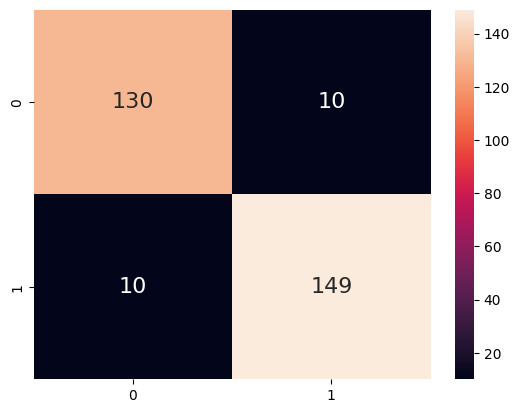

In [27]:
# Plotar Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', annot_kws={"size": 16})

In [28]:
# Classification Report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.93      0.93       140
           1       0.94      0.94      0.94       159

    accuracy                           0.93       299
   macro avg       0.93      0.93      0.93       299
weighted avg       0.93      0.93      0.93       299



In [29]:
# Acurácia do modelo
accuracy = accuracy_score(y_test, y_pred)
print(f"Acurácia: {accuracy:.2f}")

Acurácia: 0.93


# Conclusões

- O modelo teve desempenho excelente considerando o número de variáveis e o tamanho do dataset. Tivemos 93% de Acurácia e de F1-Score.
- Considerando que se trata de um caso clínico, poderíamos preferir um recall ainda maior. Os 10 presentes já seriam um problema.
- Isso poderia ser alcançado com mais variáveis preditoras.